In [7]:
from pathlib import Path
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder, find_peaks
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Paths
cutout_dir = Path("../data/raw/v854_cen_dasch/cutouts")
output_dir = Path("../outputs/tables")
os.makedirs(output_dir, exist_ok=True)

# Detection parameters
FWHM = 3.0
THRESHOLD_SIGMA = 5.0
MIN_SOURCES_DAO = 5   # fall back to find_peaks if DAOStarFinder finds fewer than this
BOX_SIZE = 11         # for find_peaks

cutouts = sorted(cutout_dir.glob("*.fits"))
print(f"Found {len(cutouts)} cutouts to process")

Found 4540 cutouts to process


In [10]:
def detect_sources(fits_path):
    """
    Run source detection on a single cutout FITS file.
    Returns (sources, algorithm_used, data, data_sub, std)
    """
    # Load data
    data = fits.getdata(fits_path).astype(float)
    data = np.nan_to_num(data, nan=np.nanmedian(data))

    # Background stats
    mean, median, std = sigma_clipped_stats(data, sigma=3.0)
    data_sub = data - median

    # Try DAOStarFinder first 
    try:
        daofind = DAOStarFinder(
            fwhm=FWHM,
            threshold=THRESHOLD_SIGMA * std,
            sharpness_range=(0.2, 2.0)
        )
        dao_sources = daofind(data_sub)
        n_dao = 0 if dao_sources is None else len(dao_sources)
    except Exception:
        dao_sources = None
        n_dao = 0

    if n_dao >= MIN_SOURCES_DAO:
        # DAOStarFinder worked and used
        sources = dao_sources
        algorithm = "DAOStarFinder"
        x_col, y_col = "x_centroid", "y_centroid"
    else:
        # Fall back to find_peaks
        sources = find_peaks(data_sub, threshold=THRESHOLD_SIGMA * std, box_size=BOX_SIZE)
        algorithm = "find_peaks"
        x_col, y_col = "x_peak", "y_peak"

    return sources, algorithm, data, data_sub, std, x_col, y_col

Processing plates:   0%|          | 0/500 [00:00<?, ?it/s]

Done! 500 plates processed, 0 errors
algorithm
find_peaks       367
DAOStarFinder    133


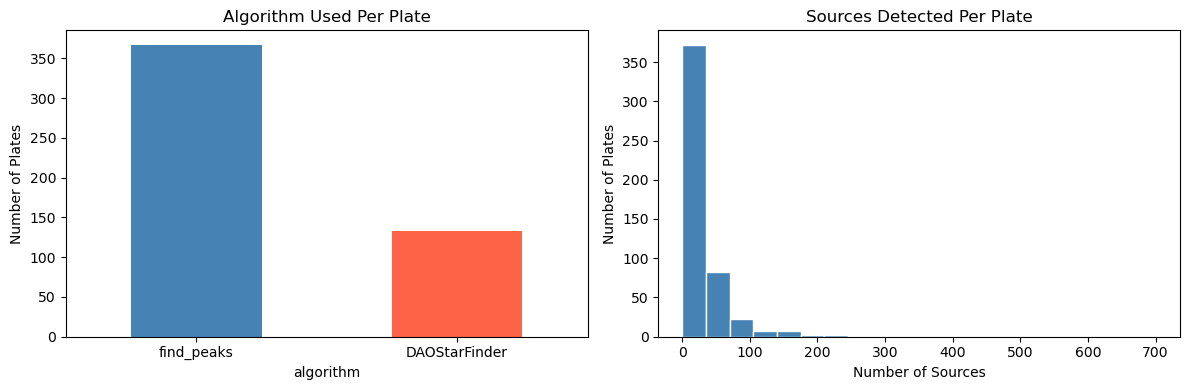

In [9]:
from tqdm.notebook import tqdm

MAX_PLATES = 500

plates_to_process = cutouts[:MAX_PLATES] if MAX_PLATES is not None else cutouts

results_summary = []
errors = []

for fits_path in tqdm(plates_to_process, desc="Processing plates"):
    try:
        sources, algorithm, data, data_sub, std, x_col, y_col = detect_sources(fits_path)
        n_sources = 0 if sources is None else len(sources)

        results_summary.append({
            "plate": fits_path.name,
            "algorithm": algorithm,
            "n_sources": n_sources
        })

        if sources is not None and n_sources > 0:
            out_path = output_dir / (fits_path.stem + "_sources.ecsv")
            sources.write(out_path, overwrite=True)

    except Exception as e:
        errors.append(f"{fits_path.name}: {e}")
        results_summary.append({
            "plate": fits_path.name,
            "algorithm": "error",
            "n_sources": 0
        })

# Save summary
summary_df = pd.DataFrame(results_summary)
summary_df.to_csv(output_dir / "detection_summary.csv", index=False)

print(f"Done! {len(plates_to_process)} plates processed, {len(errors)} errors")
print(summary_df["algorithm"].value_counts().to_string())
if errors:
    print("\nErrors:")
    for e in errors:
        print(" ", e)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

summary_df["algorithm"].value_counts().plot.bar(ax=axes[0], color=["steelblue", "tomato", "gray"])
axes[0].set_title("Algorithm Used Per Plate")
axes[0].set_ylabel("Number of Plates")
axes[0].tick_params(axis="x", rotation=0)

axes[1].hist(summary_df["n_sources"], bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Sources Detected Per Plate")
axes[1].set_xlabel("Number of Sources")
axes[1].set_ylabel("Number of Plates")

plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
from astropy.io import fits as astrofits

def get_plate_date(fits_path):
    try:
        header = astrofits.getheader(fits_path)
        # Try common date keywords in DASCH headers
        for key in ["DATE-OBS", "DATE", "DATEOBS", "MJD-OBS"]:
            if key in header:
                return str(header[key])
        return "Unknown date"
    except:
        return "Unknown date"

# Build dropdown options with dates
options = []
for f in cutouts:
    date = get_plate_date(f)
    options.append((f"{f.name}  |  {date}", f))

dropdown = widgets.Dropdown(
    options=options,
    description="Plate:"
)

output = widgets.Output()

def show_plate(change):
    with output:
        from IPython.display import clear_output
        clear_output(wait=True)

        fits_path = change["new"]
        sources, algorithm, data, data_sub, std, x_col, y_col = detect_sources(fits_path)
        n_sources = 0 if sources is None else len(sources)

        print(f"Algorithm: {algorithm}")
        print(f"Sources detected: {n_sources}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Raw plate
        axes[0].imshow(data, origin="lower", cmap="gray")
        axes[0].set_title(f"{fits_path.name}\n(raw)")

        # Detected sources
        axes[1].imshow(data, origin="lower", cmap="gray")
        if sources is not None and n_sources > 0:
            axes[1].scatter(
                sources[x_col], sources[y_col],
                s=120, facecolors="none", edgecolors="red"
            )
        axes[1].set_title(f"Detected Sources ({algorithm})")

        plt.tight_layout()
        plt.show()

dropdown.observe(show_plate, names="value")
display(dropdown, output)

Dropdown(description='Plate:', options=(('00000_b03435m0s0.fits  |  1889-06-08T02:35:07.000', WindowsPath('../…

Output()